In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.metrics import confusion_matrix, classification_report
from logic.database import AA_PROPERTIES, AA_CLASS
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster


In [2]:
AA_VOLUME_CLASS = {
    'G': 'very_small', 'A': 'very_small', 'S': 'very_small',
    'T': 'small', 'C': 'small', 'P': 'small', 'D': 'small', 'N': 'small',
    'V': 'medium', 'H': 'medium', 'E': 'medium', 'Q': 'medium',
    'I': 'large', 'L': 'large', 'M': 'large', 'K': 'large', 'R': 'large',
    'F': 'very_large', 'W': 'very_large', 'Y': 'very_large',
}

In [3]:
amino_acids = list(AA_PROPERTIES.keys())

df = pd.DataFrame({
    'volume': [AA_PROPERTIES[aa]['volume'] for aa in amino_acids],
    'hydrophobicity': [AA_PROPERTIES[aa]['hydrophobicity'] for aa in amino_acids],
    'charge': [AA_PROPERTIES[aa]['charge'] for aa in amino_acids],
}, index=amino_acids)

df_weighted = pd.DataFrame({
    'volume':        80 * df['volume'],
    'charge':        20  * df['charge'],
    'hydrophobicity': 15 * df['hydrophobicity'],
}, index=amino_acids)

In [4]:

ALPHA           = 80   # pA — how much volume affects current (bigger AA = more blockage) #used to be 20, changed alpha and beta so that peptide has a larger effect on the current
BETA            = 20   # pA — how much charge affects current per unit charge #used to be 5
GAMMA          = 15   # pA — how much hydrophobicity affects current per unit (0-1) hydrophobicity
pep_baseline = 0.5
IOS=240
weighted_volume         =  df_weighted['volume']
weighted_charge         =  df_weighted['charge']
weighted_hydrophobicity =  df_weighted['hydrophobicity']


df_weighted['score'] = (pep_baseline*IOS
            - weighted_volume
            - weighted_charge
            - weighted_hydrophobicity)


### Rebuild linkage matrix (same as 09_clustering)

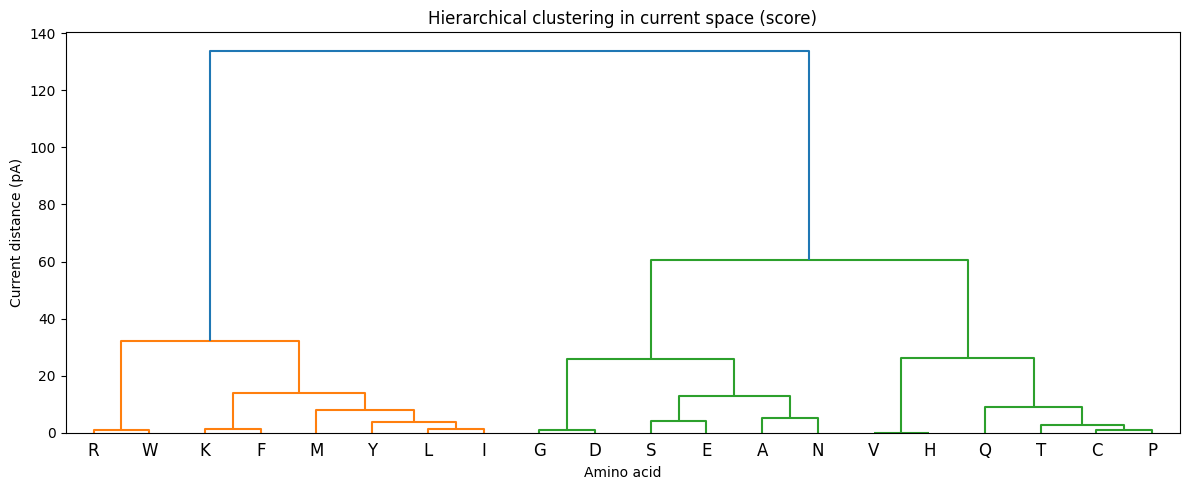

In [5]:
# Cluster in current (score) space
X_current = df_weighted['score'].values.reshape(-1, 1)

linkage_matrix_current = linkage(X_current, method='ward')

fig, ax = plt.subplots(figsize=(12, 5))
dendrogram(linkage_matrix_current, labels=amino_acids, ax=ax)
ax.set_title('Hierarchical clustering in current space (score)')
ax.set_xlabel('Amino acid')
ax.set_ylabel('Current distance (pA)')
plt.tight_layout()
plt.show()

# n_clusters = 4
# labels_current = fcluster(linkage_matrix_current, n_clusters, criterion='maxclust')
# cluster_df_current = pd.DataFrame({'AA': amino_acids, 'cluster': labels_current, 'score': df_weighted['score']})
# cluster_df_current = cluster_df_current.sort_values('score')
# for c in sorted(cluster_df_current['cluster'].unique()):
#     members = cluster_df_current[cluster_df_current['cluster'] == c]['AA'].tolist()
#     print(f"Cluster {c}: {members}")
#     for aa in members:
#         print(f"{aa}: class={AA_CLASS[aa]}, volume_class={AA_VOLUME_CLASS[aa]}")
#     print(f"Cluster {c} classes: {[AA_CLASS[aa] for aa in members]}")
#     print(f"Cluster {c} volume classes: {[AA_VOLUME_CLASS[aa] for aa in members]}")
#     print("----------------------------------------------------------------")

### Load pre-extracted window features

### Load full training pool and fixed test set

In [6]:
all_train = pd.read_csv('../data/nanopore_feature_by_cluster.csv')
test_base_raw = pd.read_csv('../data/randomcontrol_feature_by_cluster.csv')
print(f"Training pool: {all_train['trace_id'].nunique()} traces, {len(all_train)} rows")
print(f"Fixed test set: {test_base_raw['trace_id'].nunique()} traces, {len(test_base_raw)} rows")

Training pool: 10000 traces, 199981 rows
Fixed test set: 10000 traces, 199981 rows


### Define models, feature columns, and CV strategy

In [11]:
feature_cols = [
    'mean_current',
    # 'weighted_window_current',
    'mean_minus2',
    'mean_minus1',
    'mean_plus1',
    'mean_plus2'

]

models = {
    # 'GaussianNB': GaussianNB(),
    'LogisticRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(class_weight='balanced', max_iter=1000))
    ]),
    'RandomForest': RandomForestClassifier(
        n_estimators=200, class_weight='balanced', random_state=42
    )
}

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    'macro_f1':    'f1_macro',
    'weighted_f1': 'f1_weighted',
    'accuracy':    'accuracy',
}

In [8]:
LABEL_MAP = {
    4: {
        1: '1: [R, W, F, K, Y, I, L]',
        2: '2: [S, E, G, D]',
        3: '3: [C, P, T, N, A]',
        4: "4: ['M', 'V', 'H', 'Q']"
        },
    5: {
        1: "1: ['R', 'W']",
        2: "2: ['F', 'K', 'Y', 'I', 'L']",
        3: "3: ['S', 'E', 'G', 'D']",
        4: "4: ['C', 'P', 'T', 'N', 'A']",
        5: "5: ['M', 'V', 'H', 'Q']"
        },
    6: {
        1: "1: ['R', 'W']",
        2: "2: ['F', 'K', 'Y', 'I', 'L']",
        3: "3: ['S', 'E', 'G', 'D']",
        4: "4: ['C', 'P', 'T', 'N', 'A']",
        5: "5: ['H', 'Q']",
        6: "6: ['M', 'V']"
    },
    7: {
        1: "1: ['R', 'W']",
        2: "2: ['F', 'K', 'Y', 'I', 'L']",
        3: "3: ['G', 'D']",
        4: "4: ['S', 'E']",
        5: "5: ['C', 'P', 'T', 'N', 'A']",
        6: "6: ['H', 'Q']",
        7: "7: ['M', 'V']"
    }
}

In [9]:
COLOR_MAP = {
    4: {
        1: 'blue',
        2: 'orange',
        3: 'green',
        4: 'red'
    },
    5: {
        1: 'blue',
        2: 'orange',
        3: 'green',
        4: 'red',
        5: 'purple'
    },
    6: {
        1: 'blue',
        2: 'orange',
        3: 'green',
        4: 'red',
        5: 'purple',
        6: 'brown'
    },
    7: {
        1: 'blue',
        2: 'orange',
        3: 'green',
        4: 'red',
        5: 'purple',
        6: 'brown',
        7: 'cyan'
    }
}

### Sweep over n_traces × n_clusters — fixed test set evaluation

In [12]:
from sklearn.base import clone
from sklearn.metrics import f1_score

TRACE_COUNTS  = [10000]
CLUSTER_RANGE = range(4, 8)

results   = []
memberships = {}

for n_clusters in CLUSTER_RANGE:
    raw_labels   = fcluster(linkage_matrix_current, n_clusters, criterion='maxclust')
    label_lookup = LABEL_MAP.get(n_clusters, {})
    aa_to_cluster = {
        aa: label_lookup.get(int(raw_labels[i]), f'cluster_{raw_labels[i]}')
        for i, aa in enumerate(amino_acids)
    }

    memberships[n_clusters] = (
        pd.DataFrame({'AA': amino_acids,
                      'cluster': [aa_to_cluster[aa] for aa in amino_acids]})
        .sort_values('cluster')
        .reset_index(drop=True)
    )

    # Build fixed test set once per cluster config
    test_df = test_base_raw.copy()
    test_df['cluster_label'] = test_df['amino_acid'].map(aa_to_cluster)
    X_test = test_df[feature_cols].values
    y_test = test_df['cluster_label'].values
    test_mask = ~np.isnan(X_test).any(axis=1)
    X_test, y_test = X_test[test_mask], y_test[test_mask]

    for n_traces in TRACE_COUNTS:
        train_df = all_train[all_train['trace_id'] < n_traces].copy()
        train_df['cluster_label'] = train_df['amino_acid'].map(aa_to_cluster)
        X_train = train_df[feature_cols].values
        y_train = train_df['cluster_label'].values
        train_mask = ~np.isnan(X_train).any(axis=1)
        X_train, y_train = X_train[train_mask], y_train[train_mask]

        for model_name, model in models.items():
            m = clone(model)
            m.fit(X_train, y_train)
            y_pred = m.predict(X_test)
            results.append({
                'n_traces':    n_traces,
                'n_clusters':  n_clusters,
                'model':       model_name,
                'accuracy':    (y_pred == y_test).mean(),
                'macro_f1':    f1_score(y_test, y_pred, average='macro'),
                'weighted_f1': f1_score(y_test, y_pred, average='weighted'),
            })

    print(f"n_clusters={n_clusters} done.")

results_df = pd.DataFrame(results)
print(results_df)



n_clusters=4 done.
n_clusters=5 done.
n_clusters=6 done.
n_clusters=7 done.
   n_traces  n_clusters               model  accuracy  macro_f1  weighted_f1
0     10000           4  LogisticRegression  0.757172  0.741916     0.759795
1     10000           4        RandomForest  0.725827  0.692979     0.718902
2     10000           5  LogisticRegression  0.698794  0.701339     0.698357
3     10000           5        RandomForest  0.664135  0.653319     0.659150
4     10000           6  LogisticRegression  0.638415  0.612742     0.644658
5     10000           6        RandomForest  0.633665  0.532757     0.605718
6     10000           7  LogisticRegression  0.578005  0.567382     0.586394
7     10000           7        RandomForest  0.583786  0.477309     0.544323


In [12]:
from sklearn.base import clone
from sklearn.metrics import f1_score

TRACE_COUNTS  = [10000]

results   = []
memberships = {}
n_clusters = 7
raw_labels   = fcluster(linkage_matrix_current, n_clusters, criterion='maxclust')
label_lookup = LABEL_MAP.get(n_clusters, {})
aa_to_cluster = {
    aa: label_lookup.get(int(raw_labels[i]), f'cluster_{raw_labels[i]}')
    for i, aa in enumerate(amino_acids)
}

memberships[n_clusters] = (
    pd.DataFrame({'AA': amino_acids,
                    'cluster': [aa_to_cluster[aa] for aa in amino_acids]})
    .sort_values('cluster')
    .reset_index(drop=True)
)

# Build fixed test set once per cluster config
test_df = test_base_raw.copy()
test_df['cluster_label'] = test_df['amino_acid'].map(aa_to_cluster)
X_test = test_df[feature_cols].values
y_test = test_df['cluster_label'].values
test_mask = ~np.isnan(X_test).any(axis=1)
X_test, y_test = X_test[test_mask], y_test[test_mask]

for n_traces in TRACE_COUNTS:
    train_df = all_train[all_train['trace_id'] < n_traces].copy()
    train_df['cluster_label'] = train_df['amino_acid'].map(aa_to_cluster)
    X_train = train_df[feature_cols].values
    y_train = train_df['cluster_label'].values
    train_mask = ~np.isnan(X_train).any(axis=1)
    X_train, y_train = X_train[train_mask], y_train[train_mask]

    for model_name, model in models.items():
        m = clone(model)
        m.fit(X_train, y_train)
        y_pred = m.predict(X_test)
        results.append({
            'n_traces':    n_traces,
            'n_clusters':  n_clusters,
            'model':       model_name,
            'accuracy':    (y_pred == y_test).mean(),
            'macro_f1':    f1_score(y_test, y_pred, average='macro'),
            'weighted_f1': f1_score(y_test, y_pred, average='weighted'),
        })

    print(f"n_clusters={n_clusters} done.")

results_df = pd.DataFrame(results)
print(results_df)



n_clusters=7 done.
   n_traces  n_clusters               model  accuracy  macro_f1  weighted_f1
0     10000           7  LogisticRegression  0.562142   0.56575     0.562852
1     10000           7        RandomForest  1.000000   1.00000     1.000000


In [15]:
# with pd.option_context('display.max_rows', None):
#     display(results_df)

In [14]:
pd.set_option('display.max_rows', None)
results_df.sort_values(['weighted_f1'], ascending=False)

,n_traces,n_clusters,model,accuracy,macro_f1,weighted_f1
0,10000,4,LogisticRegression,0.757172,0.741916,0.759795
1,10000,4,RandomForest,0.725827,0.692979,0.718902
2,10000,5,LogisticRegression,0.698794,0.701339,0.698357
3,10000,5,RandomForest,0.664135,0.653319,0.659150
4,10000,6,LogisticRegression,0.638415,0.612742,0.644658
5,10000,6,RandomForest,0.633665,0.532757,0.605718
6,10000,7,LogisticRegression,0.578005,0.567382,0.586394
7,10000,7,RandomForest,0.583786,0.477309,0.544323


In [58]:
logistic = results_df[results_df['model'] == 'LogisticRegression']
logistic.sort_values(['n_clusters'], ascending=False)

,n_traces,n_clusters,model,accuracy,macro_f1,weighted_f1
6,10000,7,LogisticRegression,0.578005,0.567382,0.586394
4,10000,6,LogisticRegression,0.638415,0.612742,0.644658
2,10000,5,LogisticRegression,0.698794,0.701339,0.698357
0,10000,4,LogisticRegression,0.757172,0.741916,0.759795


### Summary plot — performance vs n_traces, coloured by n_clusters

In [15]:
TRACE_COUNTS  = [2000, 5000, 8000, 10000]
CLUSTER_RANGE = range(4, 8)

metrics     = [('macro_f1', 'Macro F1'), ('accuracy', 'Accuracy')]
model_names = list(models.keys())
cluster_colors = {n: plt.cm.tab10(i) for i, n in enumerate(CLUSTER_RANGE)}


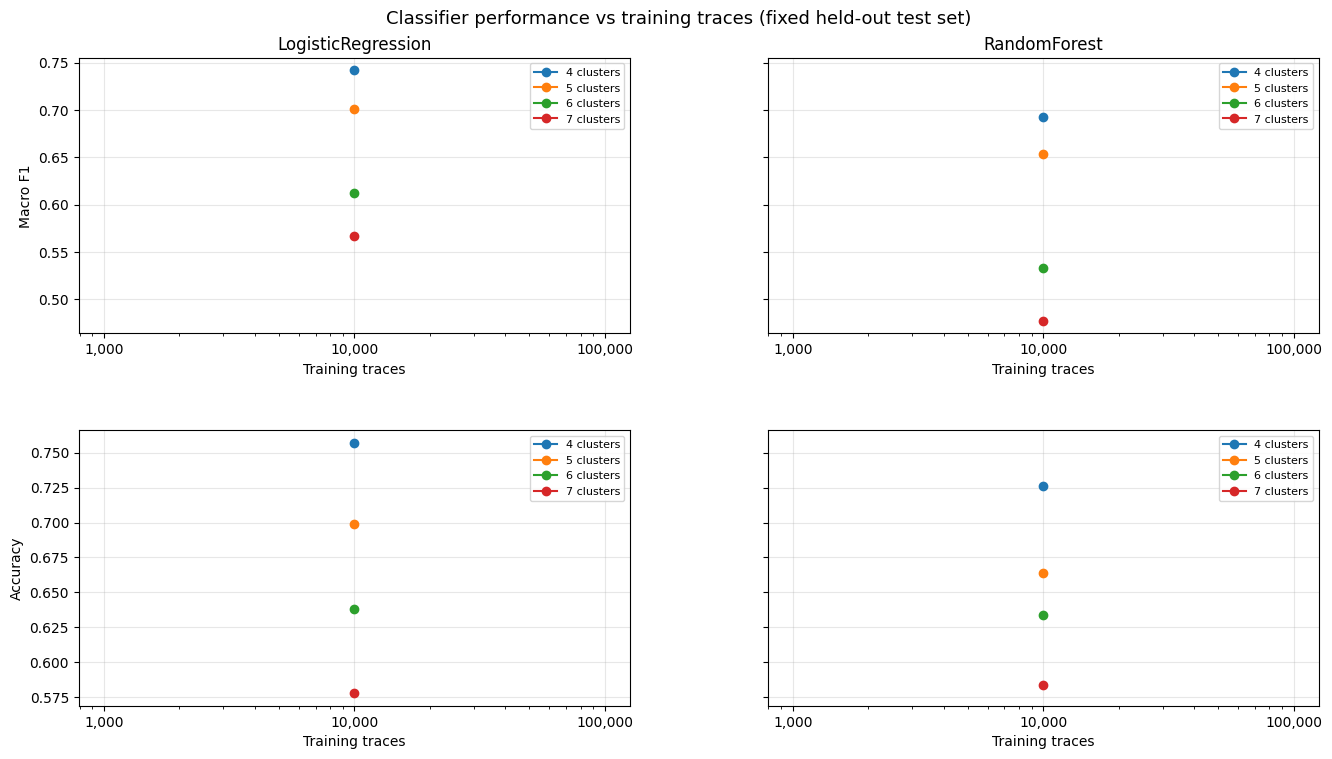

In [16]:
from matplotlib.ticker import FuncFormatter
# results_df = pd.read_csv('../data/classification_results_by_cluster.csv')  # uncomment to skip re-running

metrics     = [('macro_f1', 'Macro F1'), ('accuracy', 'Accuracy')]
model_names = list(models.keys())
cluster_colors = {n: plt.cm.tab10(i) for i, n in enumerate(CLUSTER_RANGE)}

fig, axes = plt.subplots(len(metrics), len(model_names), figsize=(16, 8), sharey='row')

for row, (metric, metric_label) in enumerate(metrics):
    for col, model_name in enumerate(model_names):
        ax = axes[row][col]
        for n_clusters in CLUSTER_RANGE:
            sub = (results_df
                   [(results_df['model'] == model_name) &
                    (results_df['n_clusters'] == n_clusters)]
                   .sort_values('n_traces'))
            ax.plot(sub['n_traces'], sub[metric],
                    marker='o', label=f'{n_clusters} clusters',
                    color=cluster_colors[n_clusters])
        ax.set_xscale('log')
        ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))
        ax.set_xlabel('Training traces')
        if col == 0:
            ax.set_ylabel(metric_label)
        if row == 0:
            ax.set_title(model_name)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

plt.suptitle('Classifier performance vs training traces (fixed held-out test set)', fontsize=13)
plt.subplots_adjust(top=0.92, hspace=0.35, wspace=0.25)
plt.show()

In [17]:
TRACE_COUNTS  = [100, 250, 500, 1000, 2000, 5000, 8000, 10000]
CLUSTER_RANGE = range(4, 8)

metrics     = [('macro_f1', 'Macro F1'), ('accuracy', 'Accuracy')]
model_names = list(models.keys())
cluster_colors = {n: plt.cm.tab10(i) for i, n in enumerate(CLUSTER_RANGE)}


### Pivot table — macro F1 at a glance

In [17]:
PIVOT_N_TRACES = 10000  # show results at max trace count

pivot = (
    results_df[results_df['n_traces'] == PIVOT_N_TRACES]
    .pivot(index='n_clusters', columns='model', values='macro_f1')
    .round(3)
)
pivot.index.name = 'n_clusters'
print(f"Macro F1 at n_traces={PIVOT_N_TRACES} (fixed test set):")
pivot

Macro F1 at n_traces=10000 (fixed test set):


model,LogisticRegression,RandomForest
n_clusters,,
4,0.742,0.693
5,0.701,0.653
6,0.613,0.533
7,0.567,0.477


### Inspect cluster memberships for a chosen n_clusters

Change `INSPECT_N` to any value in `CLUSTER_RANGE` to see what's in each cluster.

In [18]:
INSPECT_N = 4 # change this

print(f"Cluster memberships for n_clusters={INSPECT_N}:")
for cluster_id, grp in memberships[INSPECT_N].groupby('cluster'):
    print(f"  {cluster_id}: {grp['AA'].tolist()}")

Cluster memberships for n_clusters=4:
  1: [R, W, F, K, Y, I, L]: ['W', 'F', 'R', 'K', 'I', 'L', 'Y']
  2: [S, E, G, D]: ['G', 'D', 'S', 'E']
  3: [C, P, T, N, A]: ['N', 'C', 'P', 'T', 'A']
  4: ['M', 'V', 'H', 'Q']: ['Q', 'M', 'H', 'V']


### Confusion matrix for a chosen n_clusters + model

Set `BEST_N` and `BEST_MODEL_NAME` based on what the summary plot shows.

In [1]:
BEST_N        = 4
BEST_N_TRACES = 10000
BEST_MODEL_NAME = 'LogisticRegression'

raw_labels = fcluster(linkage_matrix_current, BEST_N, criterion='maxclust')
label_lookup = LABEL_MAP.get(BEST_N, {})
aa_to_cluster = {
    aa: label_lookup.get(int(raw_labels[i]), f'cluster_{raw_labels[i]}')
    for i, aa in enumerate(amino_acids)
}

train_df = all_train[all_train['trace_id'] < BEST_N_TRACES].copy()
train_df['cluster_label'] = train_df['amino_acid'].map(aa_to_cluster)
X_train = train_df[feature_cols].values
y_train = train_df['cluster_label'].values
train_mask = ~np.isnan(X_train).any(axis=1)
X_train, y_train = X_train[train_mask], y_train[train_mask]

test_df = test_base_raw.copy()
test_df['cluster_label'] = test_df['amino_acid'].map(aa_to_cluster)
X_test = test_df[feature_cols].values
y_test = test_df['cluster_label'].values
test_mask = ~np.isnan(X_test).any(axis=1)
X_test, y_test = X_test[test_mask], y_test[test_mask]

best_model = clone(models[BEST_MODEL_NAME])
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

cluster_order = sorted(set(y_test))
cm_counts = confusion_matrix(y_test, y_pred, labels=cluster_order)
cm_norm   = cm_counts.astype(float) / cm_counts.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, cm, title, fmt in zip(
    axes,
    [cm_counts, cm_norm],
    ['Counts', 'Row-normalised (recall)'],
    ['d', '.2f'],
):
    sns.heatmap(
        cm, annot=True, fmt=fmt, cmap='Blues',
        xticklabels=cluster_order, yticklabels=cluster_order,
        linewidths=0.5, ax=ax,
    )
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'{BEST_MODEL_NAME} — {title}')

plt.suptitle(
    f'{BEST_MODEL_NAME}, n_clusters={BEST_N}, n_traces={BEST_N_TRACES} — fixed test set',
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred, labels=cluster_order, target_names=cluster_order))

NameError: name 'fcluster' is not defined